# Benchmarks for Microgrid environment

The notebook provides testing and comparison between deterministic policies and a pretrained RL agent strategies among the `MicroGridEnv` environment.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%cd ../..

/home/andreabarisione/ErNESTO-gym


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from tqdm import tqdm
from collections import OrderedDict, defaultdict
from gymnasium.utils.env_checker import check_env
import gymnasium as gym

from ernestogym.envs.single_agent.env_new import MicroGridEnv
from ernestogym.envs.single_agent.utils import parameter_generator

In [3]:
sns.set_style('darkgrid')
plot_colors = sns.color_palette()
sns.set(font_scale=1.2)

alg_color = OrderedDict({
    'random': plot_colors[0],
    'only_market': plot_colors[1],
    'battery_first': plot_colors[2],
    '50-50': plot_colors[3],
    'ppo': plot_colors[4]
})

alg_markers = OrderedDict({
    'random': '.',
    'only_market': 'o',
    'battery_first': 'v',
    '50-50': 'P',
    'ppo': '*',
})

alg_labels = {
    'random': 'Random',
    'only_market': 'OM',
    'battery_first': 'BF',
    '50-50': '50-50',
    'ppo': 'PPO',
}

In [4]:
# IF RESULTS ARE ALREADY AVAILABLE, GO TO LAST CELLS TO LOAD THEM FROM JSON FILE AND DIRECTLY PLOT THEM!!

## Deterministic policies
Here we can evaluate different rule-based and deterministic policies.
Hereafter we will test:
1. random action policy
2. market-only policy
3. battery-first policy
5. 50/50 policy

In [5]:
params = parameter_generator(world_options='ernestogym/envs/single_agent/ijcnn_deg_test_cell.yaml')
env = gym.make(id="ernestogym/micro_grid-v1", **{'settings':params})

++++++ INITIALIZING ENV +++++++
[INIT] Environment created with seed 46


In [6]:
params['battery']['params']['nominal_cost'] = 10.5
params

{'battery': {'sign_convention': 'passive',
  'params': {'nominal_voltage': 3.65,
   'nominal_capacity': 20.0,
   'nominal_dod': 0.8,
   'nominal_lifetime': 3000,
   'v_max': 4.15,
   'v_min': 3.0,
   'temp_ambient': 298.15,
   'nominal_cost': 10.5},
  'bounds': {'voltage': {'low': 3.0, 'high': 4.15},
   'current': {'low': -60.0, 'high': 20.0},
   'power': {'low': -249.0, 'high': 83},
   'temperature': {'low': 273.15, 'high': 323.15},
   'temp_ambient': {'low': 273.15, 'high': 313.15},
   'soc': {'low': 0.1, 'high': 1.0},
   'soh': {'low': 0.6, 'high': 1.0}},
  'init': {'voltage': 3.0,
   'current': 0.0,
   'power': 0.0,
   'temperature': 293.15,
   'temp_ambient': 293.15,
   'soc': 1.0,
   'soh': 1.0}},
 'input_var': 'power',
 'models_config': [{'type': 'electrical',
   'class_name': 'TheveninModel',
   'use_fading': False,
   'components': {'r0': {'selected_type': 'lookup',
     'scalar': 10.0,
     'lookup': {'table': 'r0_cell.csv',
      'inputs': [{'var': 'temperature', 'label': 't

In [7]:
# Test profiles belonging to the test set
test_profiles = [i for i in range(370, 398)]
rewards = defaultdict(dict)

<h3> Random Policy: </h3>
The action is chosen randomly at each decision step.

In [8]:
alg = 'random'
rewards[alg] = {}

for profile in tqdm(test_profiles):
    obs, info = env.reset(options={'eval_profile': str(profile)})
    done = False
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['weigh'] = []
    rewards[alg][profile]['norm'] = []

    while not done:
        action = env.action_space.sample()  # Randomly select an action
        obs, reward, terminated, truncated, info = env.step(action)  
        done = terminated or truncated
        rewards[alg][profile]['pure'].append(list(info['pure_rewards'].values()))
        rewards[alg][profile]['norm'].append(list(info['norm_rewards'].values()))
        rewards[alg][profile]['weigh'].append(list(info['weighted_rewards'].values()))

100%|██████████| 28/28 [00:17<00:00,  1.60it/s]


<h3> Only Market Policy: </h3>
The action chosen is always 0, meaning that the battery is never used.

In [9]:
alg = 'only_market'
rewards[alg] = {}

for profile in tqdm(test_profiles):
    obs, info = env.reset(options={'eval_profile': str(profile)})
    done = False
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['weigh'] = []
    rewards[alg][profile]['norm'] = []

    while not done:
        action = np.array([0]) # Only trading with market
        obs, reward, terminated, truncated, info = env.step(action)  
        done = terminated or truncated
        rewards[alg][profile]['pure'].append(list(info['pure_rewards'].values()))
        rewards[alg][profile]['norm'].append(list(info['norm_rewards'].values()))
        rewards[alg][profile]['weigh'].append(list(info['weighted_rewards'].values()))

100%|██████████| 28/28 [00:15<00:00,  1.75it/s]


<h3> Battery First Policy: </h3>
The action chosen is always 1, meaning that the battery is always used before interacting with the market.

In [10]:
alg = 'battery_first'
rewards[alg] = {}

for profile in tqdm(test_profiles):
    obs, info = env.reset(options={'eval_profile': str(profile)})
    done = False
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['weigh'] = []
    rewards[alg][profile]['norm'] = []

    while not done:
        action = np.array([1])  # Use the battery as much as possible 
        obs, reward, terminated, truncated, info = env.step(action)  
        done = terminated or truncated
        rewards[alg][profile]['pure'].append(list(info['pure_rewards'].values()))
        rewards[alg][profile]['norm'].append(list(info['norm_rewards'].values()))
        rewards[alg][profile]['weigh'].append(list(info['weighted_rewards'].values()))

  0%|          | 0/28 [00:00<?, ?it/s]

100%|██████████| 28/28 [00:18<00:00,  1.52it/s]


<h3> 50-50 Policy: </h3>
The action chosen is always 0.5, meaning that the battery is never used.

In [11]:
alg = '50-50'
rewards[alg] = {}

for profile in tqdm(test_profiles):
    obs, info = env.reset(options={'eval_profile': str(profile)})
    done = False
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['weigh'] = []
    rewards[alg][profile]['norm'] = []

    while not done:
        action = np.array([0.5])  # Use the battery at 50%
        obs, reward, terminated, truncated, info = env.step(action)  
        done = terminated or truncated
        rewards[alg][profile]['pure'].append(list(info['pure_rewards'].values()))
        rewards[alg][profile]['norm'].append(list(info['norm_rewards'].values()))
        rewards[alg][profile]['weigh'].append(list(info['weighted_rewards'].values()))

  0%|          | 0/28 [00:00<?, ?it/s]

100%|██████████| 28/28 [00:16<00:00,  1.72it/s]


### PPO agent
Here we load the previously created model `PPO_trained`.

In [12]:
# Uncomment the following line to install stable-baselines3
#!pip install stable-baselines3

In [13]:
from stable_baselines3 import PPO
from stable_baselines3.ppo import MlpPolicy
from stable_baselines3.common.env_util import make_vec_env

In [14]:
env = make_vec_env("ernestogym/micro_grid-v1", n_envs=1, env_kwargs={'settings':params})

alg = 'ppo'
rewards[alg] = {}

model = PPO(MlpPolicy, env, verbose=1)
vec_env = model.get_env()
# model = PPO.load("examples/single_agent/models/Weekly_experiment_longer_20250811_seed11.zip")
model = PPO.load("examples/single_agent/models/20251112_model.zip")


for profile in tqdm(test_profiles):
    vec_env.set_options({'eval_profile': str(profile)})
    obs = vec_env.reset()

    cumulated_reward = 0
    rewards[alg][profile] = {}
    rewards[alg][profile]['pure'] = []
    rewards[alg][profile]['norm'] = []
    rewards[alg][profile]['weigh'] = []
    done = False
    
    while not done:
        action, _states = model.predict(obs)
        obs, r, dones, info = vec_env.step(action)
        done = dones[0]
        rewards[alg][profile]['pure'].append(list(info[0]['pure_rewards'].values()))
        rewards[alg][profile]['norm'].append(list(info[0]['norm_rewards'].values()))
        rewards[alg][profile]['weigh'].append(list(info[0]['weighted_rewards'].values()))

/home/andreabarisione/miniconda3/envs/ernesto-gym/lib/python3.11/site-packages/gymnasium/envs/registration.py:787: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


++++++ INITIALIZING ENV +++++++
[INIT] Environment created with seed 46
Using cpu device


100%|██████████| 28/28 [00:19<00:00,  1.41it/s]


In [15]:
env

In [16]:
#import json

#with open('examples/microgrid/test_results.json', 'w') as f:
#    json.dump(rewards, f, indent=4)

## Result analysis
Here we compare the average cumulated reward across all the test profiles among the different methods.

In [17]:
#import json

#with open('examples/microgrid/test_results.json', 'r') as f:
#    rewards = json.load(f)

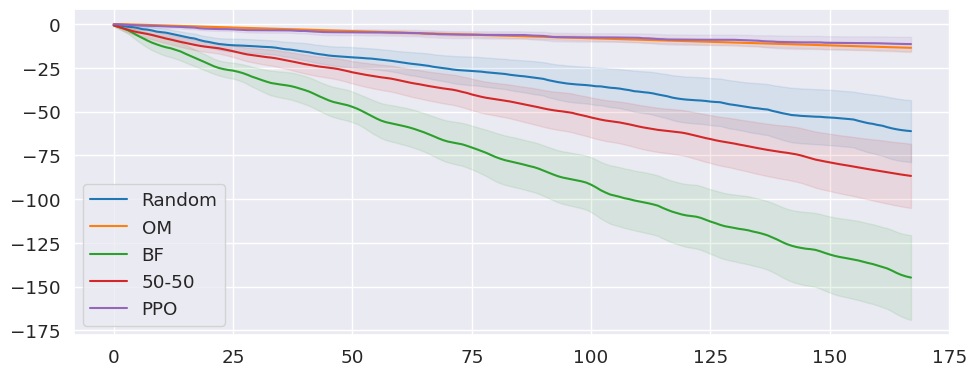

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)

for i, alg in enumerate(rewards.keys()):
    cum_rewards_pure = []
    for profile in rewards[alg].keys():
        cum_rewards_pure.append(np.cumsum([rewards[alg][profile]['pure'][i][0] + rewards[alg][profile]['pure'][i][1] + rewards[alg][profile]['pure'][i][2] for i in range(len(rewards[alg][profile]['pure']))]))

    means_pure = np.mean(cum_rewards_pure, axis=0)
    stds_pure = np.std(cum_rewards_pure, axis=0)
    ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))

    ax.plot(means_pure, label=alg_labels[alg], color=alg_color[alg])        
    ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
    ax.legend()

In [19]:
alg=['only_market','ppo']

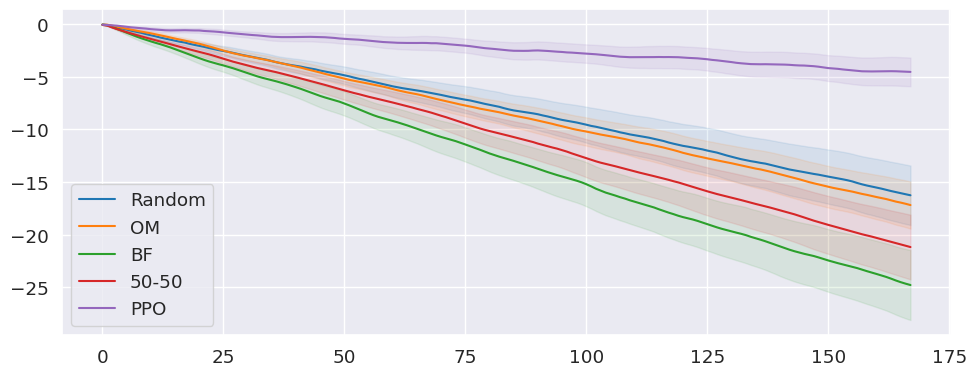

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)

for i, alg in enumerate(rewards.keys()):
    cum_rewards_norm = []
    for profile in rewards[alg].keys():
        cum_rewards_norm.append(np.cumsum([rewards[alg][profile]['norm'][i][0] + rewards[alg][profile]['norm'][i][1] + rewards[alg][profile]['norm'][i][2] for i in range(len(rewards[alg][profile]['norm']))]))

    means_norm = np.mean(cum_rewards_norm, axis=0)
    stds_norm = np.std(cum_rewards_norm, axis=0)
    ci_norm = 1.96 * stds_norm/np.sqrt(len(rewards[alg].keys()))

    ax.plot(means_norm, label=alg_labels[alg], color=alg_color[alg])        
    ax.fill_between(range(len(means_norm)), means_norm + ci_norm, means_norm - ci_norm, color=alg_color[alg], alpha=0.1)
    ax.legend()

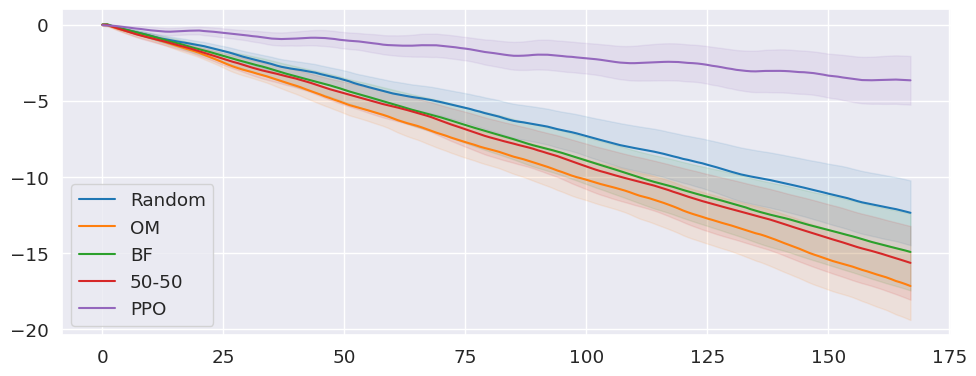

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)

for i, alg in enumerate(rewards.keys()):
    cum_rewards_weigh = []
    for profile in rewards[alg].keys():
        cum_rewards_weigh.append(np.cumsum([rewards[alg][profile]['weigh'][i][0] + rewards[alg][profile]['weigh'][i][1] + rewards[alg][profile]['weigh'][i][2] for i in range(len(rewards[alg][profile]['weigh']))]))

    means_weigh = np.mean(cum_rewards_weigh, axis=0)
    stds_weigh = np.std(cum_rewards_weigh, axis=0)
    ci_weigh = 1.96 * stds_weigh/np.sqrt(len(rewards[alg].keys()))

    ax.plot(means_weigh, label=alg_labels[alg], color=alg_color[alg])        
    ax.fill_between(range(len(means_weigh)), means_weigh + ci_weigh, means_weigh - ci_weigh, color=alg_color[alg], alpha=0.1)
    ax.legend()

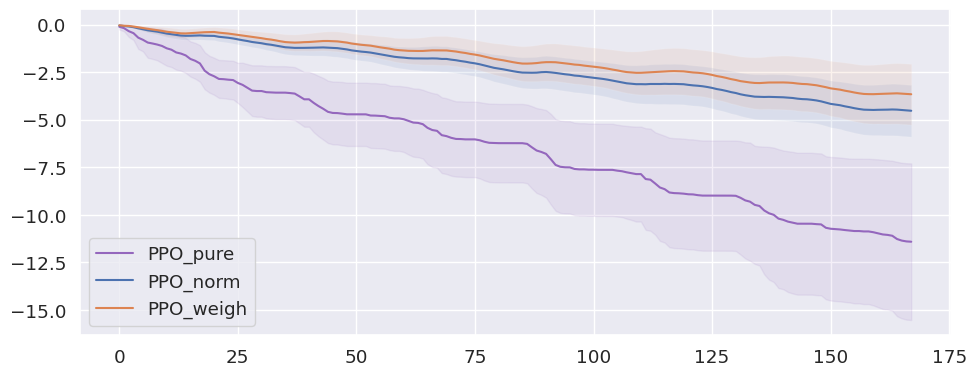

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), tight_layout=True)

# for i, alg in enumerate(rewards.keys()):
cum_rewards_pure = []
cum_rewards_norm = []
cum_rewards_weigh = []
for profile in rewards[alg].keys():
    # cum_rewards.append(np.cumsum([rewards[alg][profile]['pure'][i][0] + rewards[alg][profile]['pure'][i][1] + rewards[alg][profile]['pure'][i][2] for i in range(len(rewards[alg][profile]['pure']))]))
    # cum_rewards.append(np.cumsum([rewards['ppo'][profile]['pure'][i][0] + rewards['ppo'][profile]['pure'][i][1] + rewards['ppo'][profile]['pure'][i][2] for i in range(len(rewards['ppo'][profile]['pure']))]))    
    # cum_rewards.append(np.cumsum([rewards['ppo'][profile]['norm'][i][0] + rewards['ppo'][profile]['norm'][i][1] + rewards['ppo'][profile]['norm'][i][2] for i in range(len(rewards['ppo'][profile]['norm']))]))    
    cum_rewards_pure.append(np.cumsum([rewards['ppo'][profile]['pure'][i][0] + rewards['ppo'][profile]['pure'][i][1] + rewards['ppo'][profile]['pure'][i][2] for i in range(len(rewards['ppo'][profile]['norm']))]))    
    cum_rewards_norm.append(np.cumsum([rewards['ppo'][profile]['norm'][i][0] + rewards['ppo'][profile]['norm'][i][1] + rewards['ppo'][profile]['norm'][i][2] for i in range(len(rewards['ppo'][profile]['norm']))]))    
    cum_rewards_weigh.append(np.cumsum([rewards['ppo'][profile]['weigh'][i][0] + rewards['ppo'][profile]['weigh'][i][1] + rewards['ppo'][profile]['weigh'][i][2] for i in range(len(rewards['ppo'][profile]['norm']))]))    

means_pure = np.mean(cum_rewards_pure, axis=0)
stds_pure = np.std(cum_rewards_pure, axis=0)
ci_pure = 1.96 * stds_pure/np.sqrt(len(rewards[alg].keys()))

means_norm = np.mean(cum_rewards_norm, axis=0)
stds_norm = np.std(cum_rewards_norm, axis=0)
ci_norm = 1.96 * stds_norm/np.sqrt(len(rewards[alg].keys()))

means_weigh = np.mean(cum_rewards_weigh, axis=0)
stds_weigh = np.std(cum_rewards_weigh, axis=0)
ci_weigh = 1.96 * stds_weigh/np.sqrt(len(rewards[alg].keys()))


ax.plot(means_pure, label='PPO_pure', color=alg_color[alg])        
ax.fill_between(range(len(means_pure)), means_pure + ci_pure, means_pure - ci_pure, color=alg_color[alg], alpha=0.1)
# ax.legend()

ax.plot(means_norm, label='PPO_norm')        
ax.fill_between(range(len(means_norm)), means_norm + ci_norm, means_norm - ci_norm, alpha=0.1)
# ax.legend()

ax.plot(means_weigh, label='PPO_weigh')        
ax.fill_between(range(len(means_weigh)), means_weigh + ci_weigh, means_weigh - ci_weigh, alpha=0.1)
ax.legend()

/home/andreabarisione/miniconda3/envs/ernesto-gym/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  func(*args, **kwargs)
/home/andreabarisione/miniconda3/envs/ernesto-gym/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


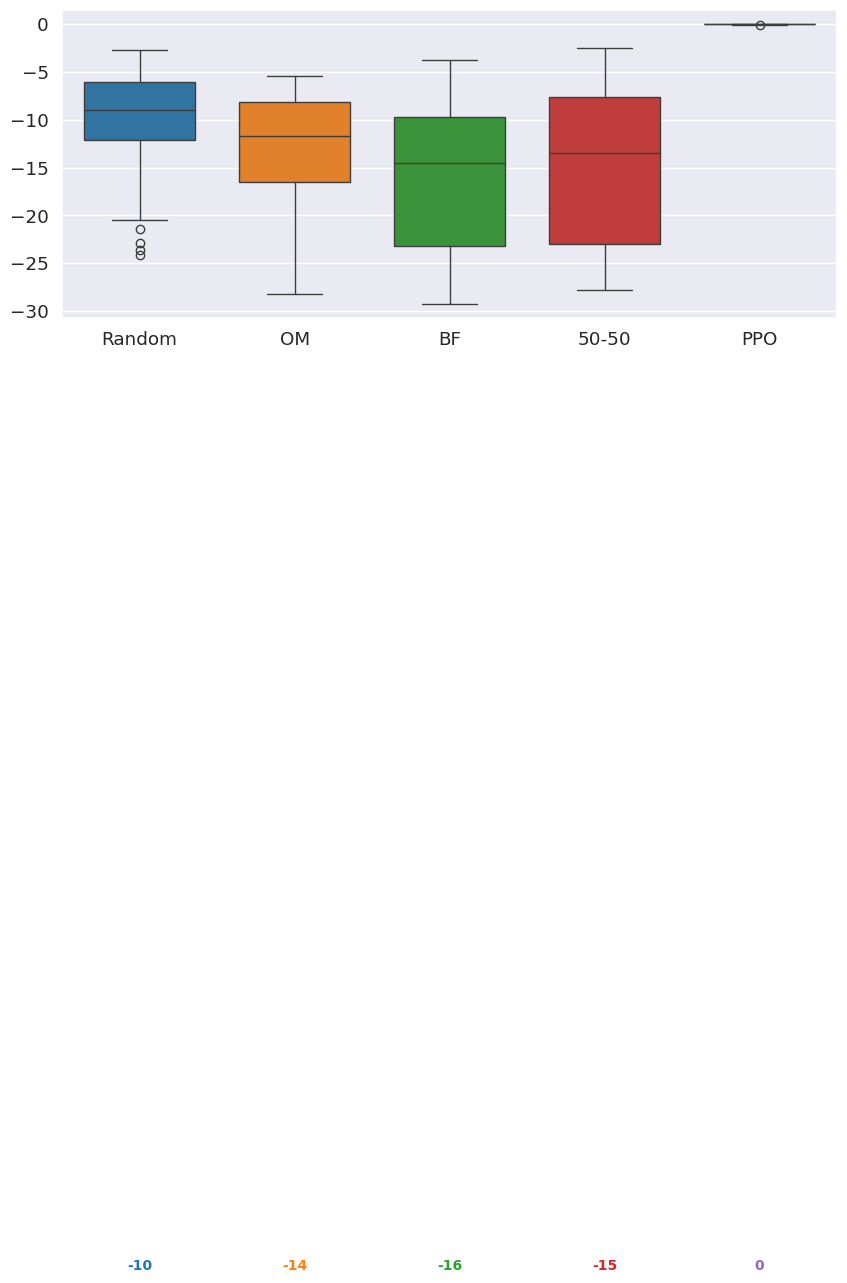

In [23]:
box_data = {}
colors = []

for alg in rewards.keys():
    box_data[alg_labels[alg]] = []
    
    for profile in rewards[alg].keys():
        total_trad = np.sum([rewards[alg][profile]['pure'][i][0] for i in range(len(rewards[alg][profile]['pure']))])
        total_deg = np.sum([rewards[alg][profile]['pure'][i][1] for i in range(len(rewards[alg][profile]['pure']))])
        box_data[alg_labels[alg]].append(total_trad + total_deg)

    colors.append(alg_color[alg])
        
fig, ax = plt.subplots(figsize=(10, 4), tight_layout=True)
box_plot = sns.boxplot(box_data, gap=.1, palette=colors, width=.8)

medians = [np.mean(values) for key, values in box_data.items()]
vertical_offset = -130 # offset from median for display

for xtick, alg in zip(box_plot.get_xticks(), rewards.keys()):
    box_plot.text(xtick, 
                  vertical_offset, 
                  round(medians[xtick]), 
                  horizontalalignment='center',
                  size='x-small', 
                  color=alg_color[alg], 
                  weight='semibold')